In [142]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt

In [143]:
class ImageData(Dataset):
    def __init__(self, input_path):
        with open(input_path, 'r') as data_file:
            self.data_list = data_file.readlines()
        self.lengh = len(self.data_list)

    def __getitem__(self, index):
        float_list = [float(el) for el in self.data_list[index].split(',')]
        tensor = torch.tensor(float_list, dtype=torch.float)

        # one-hot target
        target = torch.zeros(10)
        target[int(tensor[0])] = 1.0
        # pixels -> (1, 28, 28)
        tensor = tensor[1:].view(1, 28, 28)

        return tensor / 255.0, target

    def __len__(self):
        return self.lengh

        

In [ ]:
train_path = "mnist_train.csv"
val_path   = "mnist_test.csv"

train_data = ImageData(train_path)
val_data   = ImageData(val_path)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)


for a,b in val_loader:
    print(a.shape)
    print(b.shape)
    break

torch.Size([16, 1, 28, 28])
torch.Size([16, 10])


In [ ]:
class Model1(nn.Module):
    def __init__(self, z_size):
        super(Model1, self).__init__()

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # convolutional part
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.pool  = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)

        # fully connected part
        self.fc1 = nn.Linear(32 * 5 * 5, z_size)
        self.fc2 = nn.Linear(z_size, 10)

    def forward(self, x):
        x = self.conv1(x)      # (B, 16, 26, 26)
        x = self.relu(x)
        x = self.pool(x)       # (B, 16, 13, 13)

        x = self.conv2(x)      # (B, 32, 11, 11)
        x = self.relu(x)
        x = self.pool(x)       # (B, 32, 5, 5)

        x = x.view(x.size(0), -1)
        #Полносвязный слой
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)

        return x

In [ ]:

def log_likelihood(output, target):
    loss = nn.BCELoss()
    return loss(output, target)

In [ ]:

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)


model = Model1(z_size = 256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

train_losses = []
val_losses   = []

cpu


In [148]:
n_epochs = 6

for epoch in tqdm(range(n_epochs)):
    model.train()
    train_losses_per_epoch = []

    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data.float().to(device))
        loss = log_likelihood(output, target.to(device))
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    train_losses.append(np.mean(train_losses_per_epoch))

    model.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data.float().to(device))
            loss = log_likelihood(output, target.to(device))
            val_losses_per_epoch.append(loss.item())

    val_losses.append(np.mean(val_losses_per_epoch))

100%|██████████| 6/6 [01:13<00:00, 12.30s/it]


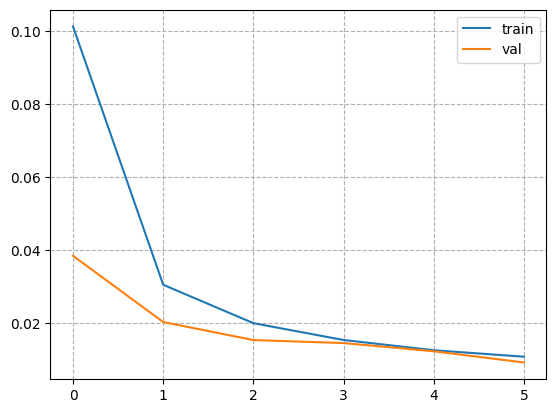

In [149]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [150]:
s_true = 0
s_false = 0

model.eval()
with torch.no_grad():
    for data, target in val_loader:
        output = model(data.float().to(device))
        output_label = torch.argmax(output, dim=1)
        target_label = torch.argmax(target.to(device), dim=1)

        for a, b in zip(output_label, target_label):
            if a == b:
                s_true += 1
            else:
                s_false += 1

print(f"точность: {s_true / (s_true + s_false):.4f}")

точность: 0.9864
